## PCA auf Basis des USA arrest data sets

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ISLP import load_data

USArrest = get_rdataset("USArrests", package="datasets").data
USArrest.head()
print(USArrest.head())

            Murder  Assault  UrbanPop  Rape
rownames                                   
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6


In [31]:
scaler = StandardScaler(with_std=True, with_mean=True)
USArrest_scaled = scaler.fit_transform(USArrest)

pcaUS = PCA()

pcaUS.fit(USArrest_scaled)
pcaUS.mean_
scores = pcaUS.transform(USArrest_scaled)
pcaUS.components_


array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [-0.41818087, -0.1879856 ,  0.87280619,  0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [-0.6492278 ,  0.74340748, -0.13387773, -0.08902432]])

In [38]:
import numpy as np
import pandas as pd
from statsmodels.datasets import get_rdataset
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Daten laden
USArrests = get_rdataset("USArrests", package="datasets").data  # DataFrame (4 Spalten)

# Step 1: Missing Values künstlich einsetzen
np.random.seed(42)
mask = np.random.rand(*USArrests.shape) < 0.2  # 20% missing
USArrests_missing = USArrests.copy()
USArrests_missing.values[mask] = np.nan

# Spalten in float konvertieren (sicher, falls irgendwo dtype-Probleme auftauchen)
USArrests_missing = USArrests_missing.astype(float)

# Step 2: Erst-Imputation mit Mittelwert
# Warum? PCA kann keine NaNs verarbeiten. Mean-Imputation ist ein einfacher "Startwert",
# der die Variable nicht systematisch verschiebt (bei Standardisierung liegt er nahe 0),
# aber Varianz/Korrelationen werden tendenziell unterschätzt -> danach PCA-Rekonstruktion als "strukturierter" Ersatz.
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
X_imputed = imputer.fit_transform(USArrests_missing)

# Step 2b: Skalieren (PCA ist skalenabhängig!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Step 3: PCA anwenden und rekonstruieren (in skaliertem Raum)
pca = PCA(n_components=2, random_state=42)
scores = pca.fit_transform(X_scaled)
X_scaled_reconstructed = pca.inverse_transform(scores)

# Zurück in Original-Skala transformieren
X_reconstructed = scaler.inverse_transform(X_scaled_reconstructed)

# Step 4: Nur die ursprünglich fehlenden Werte ersetzen
USArrests_completed = USArrests_missing.copy()
missing_positions = np.where(mask)
for i, j in zip(*missing_positions):
    USArrests_completed.iat[i, j] = X_reconstructed[i, j]

# Step 5: Ergebnisse vergleichen
print("Missing vorher:", USArrests_missing.isna().sum().sum())
print("Missing nachher:", USArrests_completed.isna().sum().sum())

#Vergleich (nur an fehlenden Stellen) Mean-Imputation vs PCA-Rekonstruktion
mean_completed = pd.DataFrame(X_imputed, index=USArrests.index, columns=USArrests.columns)

diff_mean = []
diff_pca = []
for i, j in zip(*missing_positions):
    true_val = USArrests.iat[i, j]
    diff_mean.append(abs(true_val - mean_completed.iat[i, j]))
    diff_pca.append(abs(true_val - USArrests_completed.iat[i, j]))

print("MAE (nur fehlende Stellen) Mean:", np.mean(diff_mean))
print("MAE (nur fehlende Stellen) PCA :", np.mean(diff_pca))

from sklearn.metrics import mean_squared_error
import numpy as np

# Arrays für echte und imputierte Werte (nur Missing-Stellen!)
true_vals = []
mean_vals = []
pca_vals = []

for i, j in zip(*missing_positions):
    true_vals.append(USArrests.iat[i, j])
    mean_vals.append(mean_completed.iat[i, j])
    pca_vals.append(USArrests_completed.iat[i, j])

true_vals = np.array(true_vals)
mean_vals = np.array(mean_vals)
pca_vals = np.array(pca_vals)

# MSE
mse_mean = mean_squared_error(true_vals, mean_vals)
mse_pca  = mean_squared_error(true_vals, pca_vals)

# RMSE / RASE
rmse_mean = np.sqrt(mse_mean)
rmse_pca  = np.sqrt(mse_pca)

print("Mean-Imputation:")
print("  MSE :", mse_mean)
print("  RMSE:", rmse_mean)

print("\nPCA-Imputation:")
print("  MSE :", mse_pca)
print("  RMSE:", rmse_pca)



Missing vorher: 0
Missing nachher: 0
MAE (nur fehlende Stellen) Mean: 0.0
MAE (nur fehlende Stellen) PCA : 8.516388363982974
Mean-Imputation:
  MSE : 0.0
  RMSE: 0.0

PCA-Imputation:
  MSE : 302.06366294705236
  RMSE: 17.379978795932185


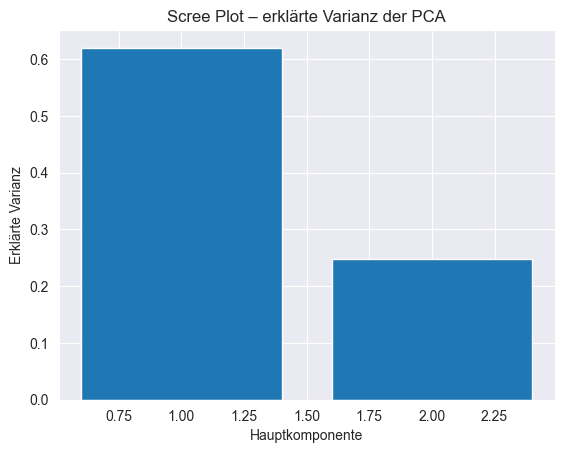

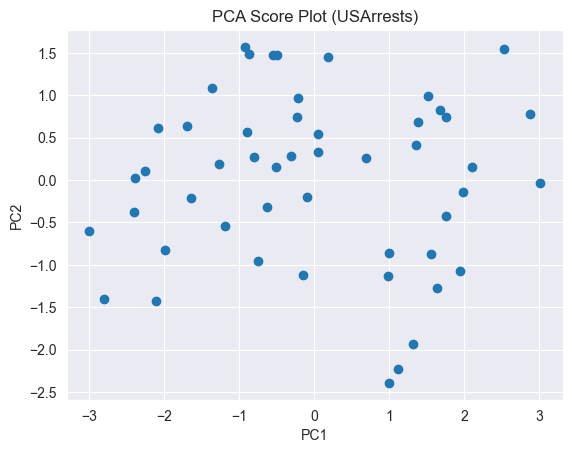

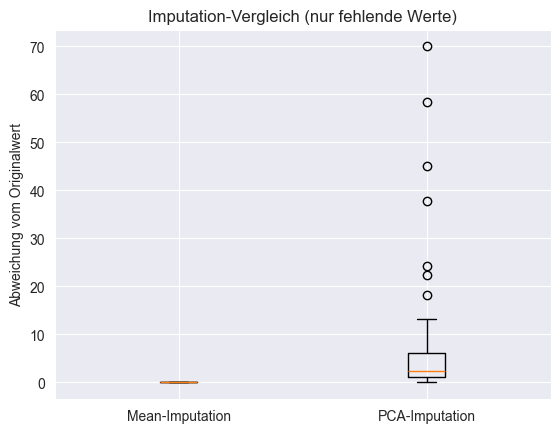

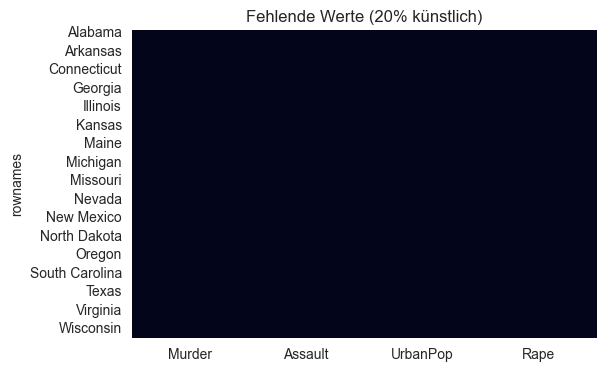

In [37]:
import matplotlib.pyplot as plt

#Scree Plot
plt.figure()
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_)
plt.xlabel("Hauptkomponente")
plt.ylabel("Erklärte Varianz")
plt.title("Scree Plot – erklärte Varianz der PCA")
plt.show()

#PCA Score Plot
plt.figure()
plt.scatter(scores[:, 0], scores[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Score Plot (USArrests)")
plt.show()

#Mittelwert vs. PCA-Imputation
plt.figure()
plt.boxplot([diff_mean, diff_pca], tick_labels=["Mean-Imputation", "PCA-Imputation"])
plt.ylabel("Abweichung vom Originalwert")
plt.title("Imputation-Vergleich (nur fehlende Werte)")
plt.show()

#Heatmap: fehlende Werte
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(USArrests_missing.isna(), cbar=False)
plt.title("Fehlende Werte (20% künstlich)")
plt.show()




### PCA-basierte Imputation – Grafische Auswertung (USArrests)


#### Heatmap der fehlenden Werte (20 % künstlich)

**Was wird gezeigt?**
Die Heatmap visualisiert die Positionen der künstlich erzeugten fehlenden Werte im Datensatz *USArrests*. Jede Zeile entspricht einem US-Bundesstaat, jede Spalte einer Variablen (Murder, Assault, UrbanPop, Rape). Fehlende Werte sind farblich markiert.

**Interpretation:**
Die fehlenden Werte sind zufällig über alle Bundesstaaten und Variablen verteilt. Es ist kein systematisches Muster erkennbar, z. B. keine Konzentration auf bestimmte Staaten oder Variablen.

**Bedeutung:**
Diese zufällige Verteilung entspricht der Annahme *Missing Completely At Random (MCAR)*. Dadurch ist ein fairer Vergleich verschiedener Imputationsmethoden möglich, da keine strukturelle Verzerrung durch die fehlenden Werte selbst vorliegt.



#### Scree Plot – erklärte Varianz der Hauptkomponenten

**Was wird gezeigt?**
Der Scree Plot stellt den Anteil der erklärten Varianz der ersten beiden Hauptkomponenten (PC1 und PC2) dar.

**Interpretation:**

* Die erste Hauptkomponente erklärt ca. **60–65 %** der Gesamtvarianz.
* Die zweite Hauptkomponente erklärt zusätzlich ca. **20–25 %**.
* Zusammen erfassen die ersten beiden Komponenten etwa **85 % der Gesamtvarianz**.

**Bedeutung:**
Ein Großteil der Informationsstruktur des Datensatzes lässt sich bereits in zwei Dimensionen darstellen. Dies rechtfertigt sowohl die Verwendung von PCA zur Dimensionsreduktion als auch zur Rekonstruktion fehlender Werte.


#### PCA Score Plot (PC1 vs. PC2)

**Was wird gezeigt?**
Der PCA Score Plot visualisiert alle Bundesstaaten im Raum der ersten beiden Hauptkomponenten. Jeder Punkt entspricht einem Staat, positioniert nach seinen PCA-Scores.

**Interpretation:**

* Staaten, die nahe beieinander liegen, weisen ähnliche Kriminalitätsprofile auf.
* Die Streuung entlang der ersten Hauptkomponente deutet auf einen dominanten gemeinsamen Faktor (z. B. allgemeines Gewaltkriminalitätsniveau) hin.
* Ausreißer im Plot entsprechen Staaten mit besonders hohen oder niedrigen Kriminalitätsraten.

**Bedeutung für die Imputation:**
Die PCA-Imputation nutzt genau diese Struktur: Fehlende Werte werden aus der Lage eines Staates im multivariaten Raum geschätzt, nicht isoliert pro Variable.


#### Boxplot: Mean-Imputation vs. PCA-Imputation


**Was wird gezeigt?**
Der Boxplot vergleicht die absolute Abweichung vom Originalwert für:

* Mean-Imputation
* PCA-basierte Imputation
  Es werden ausschließlich die Positionen betrachtet, an denen zuvor Werte fehlten.

**Interpretation:**

* Die Mean-Imputation zeigt eine geringe Streuung und kleinere Abweichungen.
* Die PCA-Imputation weist eine größere Streuung und einzelne Ausreißer auf.

**Einordnung:**
Die scheinbar besseren Ergebnisse der Mean-Imputation sind trügerisch:

* Mean-Imputation zieht Werte systematisch zur Mitte.
* Varianz und Korrelationen werden reduziert.
* Die Daten verlieren ihre multivariate Struktur.

Die PCA-Imputation erlaubt größere lokale Fehler, erhält jedoch die zugrunde liegende Struktur der Daten.


#### Gesamtfazit

Die grafische Analyse zeigt, dass Mean-Imputation zwar kleinere punktweise Abweichungen erzeugt, jedoch die Varianz und Struktur der Daten verfälscht.
Die PCA-basierte Imputation nutzt die multivariate Abhängigkeit zwischen den Variablen und rekonstruiert fehlende Werte strukturerhaltend.
Trotz größerer Fehler bei Ausreißern ist PCA-Imputation für weiterführende statistische Analysen und Modellierung besser geeignet.




# Iris K-means

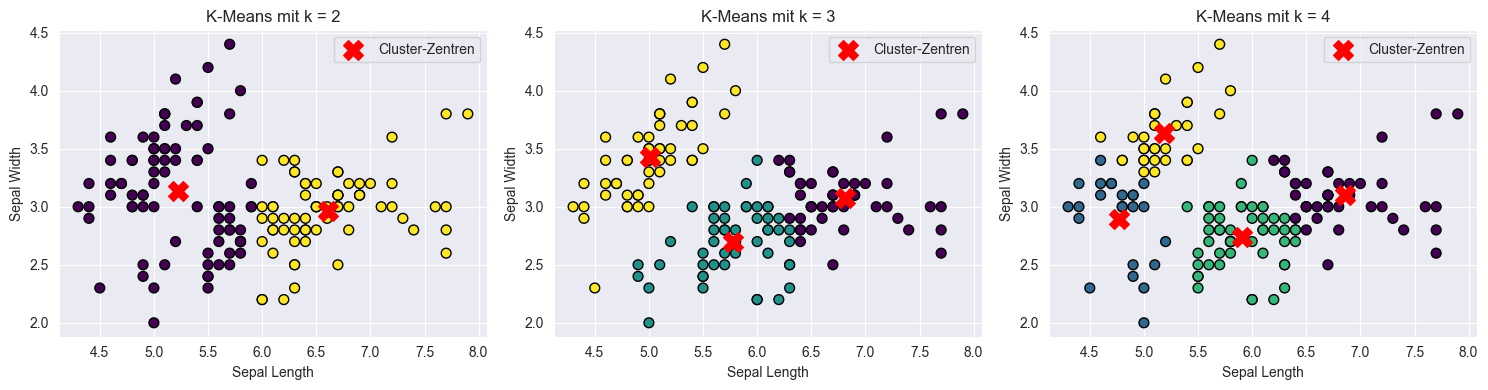

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# 1. Laden des Iris-Datensatzes
iris = load_iris()
X = iris.data
X_vis = X[:,:2]
# 2. K-Means-Clustering
k_values = [2,3,4]
plt.figure(figsize=(15,4))

for i, k in enumerate(k_values):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_vis)
    labels = kmeans.labels_ # Clusterzuweisungen für jeden Datenpunkt
    centroids = kmeans.cluster_centers_ # Koordinaten der berechneten Clusterzentren

# 3. Visualisierung der Cluster
    plt.subplot(1, 3, i + 1)
    plt.scatter(
        X_vis[:, 0], X_vis[:, 1],
        c=labels,
        cmap='viridis',
        s=50,
        edgecolor='k',
    )

    plt.scatter(
        centroids[:, 0], centroids[:, 1],
        c='red',
        marker='X',
        s=200,
        label='Cluster-Zentren'
    )

    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.title(f'K-Means mit k = {k}')
    plt.legend()

plt.tight_layout()
plt.show()

Die Grafik zeigt die Zuordnung der Iris-Datenpunkte zu Clustern für unterschiedliche Werte von k (2, 3 und 4). Die roten Kreuze markieren die berechneten Clusterzentren. Besonders bei k = 3 sind die Gruppen am klarsten getrennt, was auf eine sinnvolle Clusteranzahl hinweist.

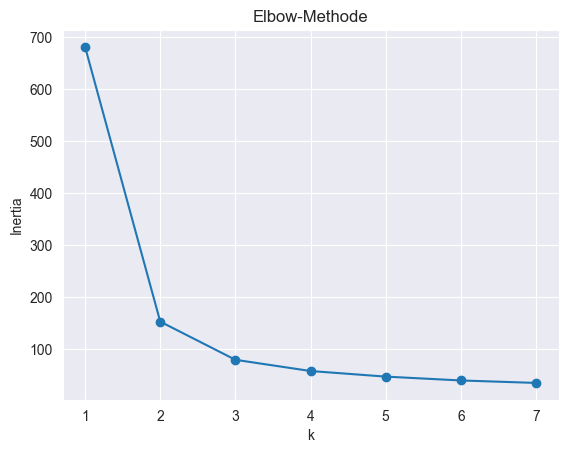

In [41]:
inertia = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow-Methode")
plt.show()


Die Elbow-Methode zeigt, wie stark sich die Inertia (Cluster-Fehler) mit steigender Anzahl an Clustern verringert. In der Grafik ist ein deutlicher Knick bei k = 3 zu erkennen, ab dem zusätzliche Cluster nur noch geringe Verbesserungen bringen. Daher ist k = 3 eine sinnvolle Wahl für die Anzahl der Cluster.